# AstroVision — Phase 6 : Incertitude & Calibration
## MC Dropout · Temperature Scaling · Conformal Prediction

**Objectif :** Quantifier et calibrer l'incertitude du classificateur morphologique.

| Méthode | Ce qu'elle mesure | Garantie |
|---|---|---|
| MC Dropout | Incertitude épistémique + aléatoire | Empirique |
| Temperature Scaling | Calibration des probabilités (ECE) | Asymptotique |
| Conformal Prediction | Ensembles avec couverture garantie | **Exacte (distribution-free)** |

**Application scientifique :**
La classe *Disturbed* (recall=0.53) n'est pas un échec — c'est de l'ambiguïté physique.
L'incertitude permet de quantifier cette ambiguïté objectivement.


## 0 — Imports & Config

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
import torch

sys.path.insert(0, str(Path('..').resolve()))
from src.astrovision.uncertainty import (
    MCDropoutPredictor, TemperatureScaler,
    ConformalPredictor, plot_uncertainty_analysis,
    find_most_uncertain
)
from src.astrovision.fusion import GalaxyFusionClassifier, FusionDataset
from src.astrovision.synthesis import DARK, CLASS_NAMES, PALETTE

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
CKPT_DIR    = Path('../checkpoints')
plt.rcParams.update(DARK)
print(f'✅ Setup OK | Device : {DEVICE}')

✅ Setup OK | Device : cuda


## 1 — Chargement du modèle et des données

In [2]:
import h5py
from sklearn.model_selection import train_test_split
from src.astrovision.fusion import build_fusion_datasets

# Data
with h5py.File(DATA_DIR / 'Galaxy10_DECals.h5', 'r') as f:
    labels_all = f['ans'][:].astype(int)

dino_features  = np.load(DATA_DIR / 'dino_features.npy')

# Morphométrie — alignement sur 17 736 galaxies
morph_df       = pd.read_pickle(DATA_DIR / 'morphometry_df.pkl')
morph_full     = pd.DataFrame({'g10_idx': np.arange(len(labels_all))})
morph_full     = morph_full.merge(
    morph_df[['g10_idx', 'C', 'A', 'S', 'Gini', 'M20']],
    on='g10_idx', how='left'
)
morph_features = morph_full[['C', 'A', 'S', 'Gini', 'M20']].values
print(f'✓ Morphometrie : {morph_features.shape}')

# Photométrie SDSS
sdss_df        = pd.read_csv(DATA_DIR / 'galaxy10_sdss_xmatch.csv.gz')
photo_df       = pd.DataFrame({'g10_idx': np.arange(len(labels_all))})
photo_df       = photo_df.merge(
    sdss_df[['g10_idx','g-r','u-r','Mr']].drop_duplicates('g10_idx'),
    on='g10_idx', how='left'
)
photo_features = photo_df[['g-r','u-r','Mr']].values
print(f'✓ Photometrie  : {photo_features.shape}')

# Splits
idx = np.arange(len(labels_all))
train_idx, temp_idx = train_test_split(idx, test_size=0.30,
    stratify=labels_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
    stratify=labels_all[temp_idx], random_state=42)

train_ds, val_ds, test_ds = build_fusion_datasets(
    dino_features, labels_all, train_idx, val_idx, test_idx,
    morph_features=morph_features, photo_features=photo_features
)
val_loader  = DataLoader(val_ds,  batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

# Modèle fusion
model = GalaxyFusionClassifier(n_morph=5, n_photo=3)
model.load_state_dict(torch.load(
    CKPT_DIR / 'fusion_dinov2_morpho_photo_best.pt',
    map_location=DEVICE
))
model = model.to(DEVICE)
print('✓ Modele fusion charge')

✓ Morphometrie : (17736, 5)
✓ Photometrie  : (17736, 3)
✓ Modele fusion charge


## 2 — MC Dropout : Incertitude épistémique

In [3]:
# MC Dropout inline — bypass MCDropoutPredictor pour FusionDataset
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import balanced_accuracy_score

T = 30
model.eval()
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.train()   # dropout actif pendant l'inférence

all_probs_runs = []
all_labels_mc  = []

with torch.no_grad():
    for t in range(T):
        probs_t = []
        for batch in test_loader:
            labels     = batch["label"]
            model_input = {k: v.to(DEVICE) for k, v in batch.items()
                           if k != "label" and isinstance(v, torch.Tensor)}
            logits = model(model_input)
            probs_t.append(torch.softmax(logits, dim=1).cpu().numpy())
            if t == 0:
                all_labels_mc.extend(labels.numpy())
        all_probs_runs.append(np.concatenate(probs_t, axis=0))
        print(f'  Pass {t+1:02d}/{T}', end='\r')

samples    = np.stack(all_probs_runs, axis=0)   # (T, N, C)
mean_probs = samples.mean(axis=0)

pred_entropy     = scipy_entropy(mean_probs, axis=1)
expected_entropy = scipy_entropy(samples, axis=2).mean(axis=0)
mutual_info      = np.clip(pred_entropy - expected_entropy, 0, None)

mc_results = {
    "mean_probs":  mean_probs,
    "variance":    samples.var(axis=0),
    "entropy":     pred_entropy,
    "mutual_info": mutual_info,
    "preds":       mean_probs.argmax(axis=1),
    "targets":     np.array(all_labels_mc),
}

print(f'\nResultats MC Dropout (T={T}, test set) :')
print(f'  Balanced Acc (mean probs) : {balanced_accuracy_score(mc_results["targets"], mc_results["preds"]):.4f}')
print(f'  Entropie moyenne          : {mc_results["entropy"].mean():.4f}')
print(f'  Info mutuelle moyenne     : {mc_results["mutual_info"].mean():.4f}')

  Pass 30/30
Resultats MC Dropout (T=30, test set) :
  Balanced Acc (mean probs) : 0.8616
  Entropie moyenne          : 0.6926
  Info mutuelle moyenne     : 0.0394


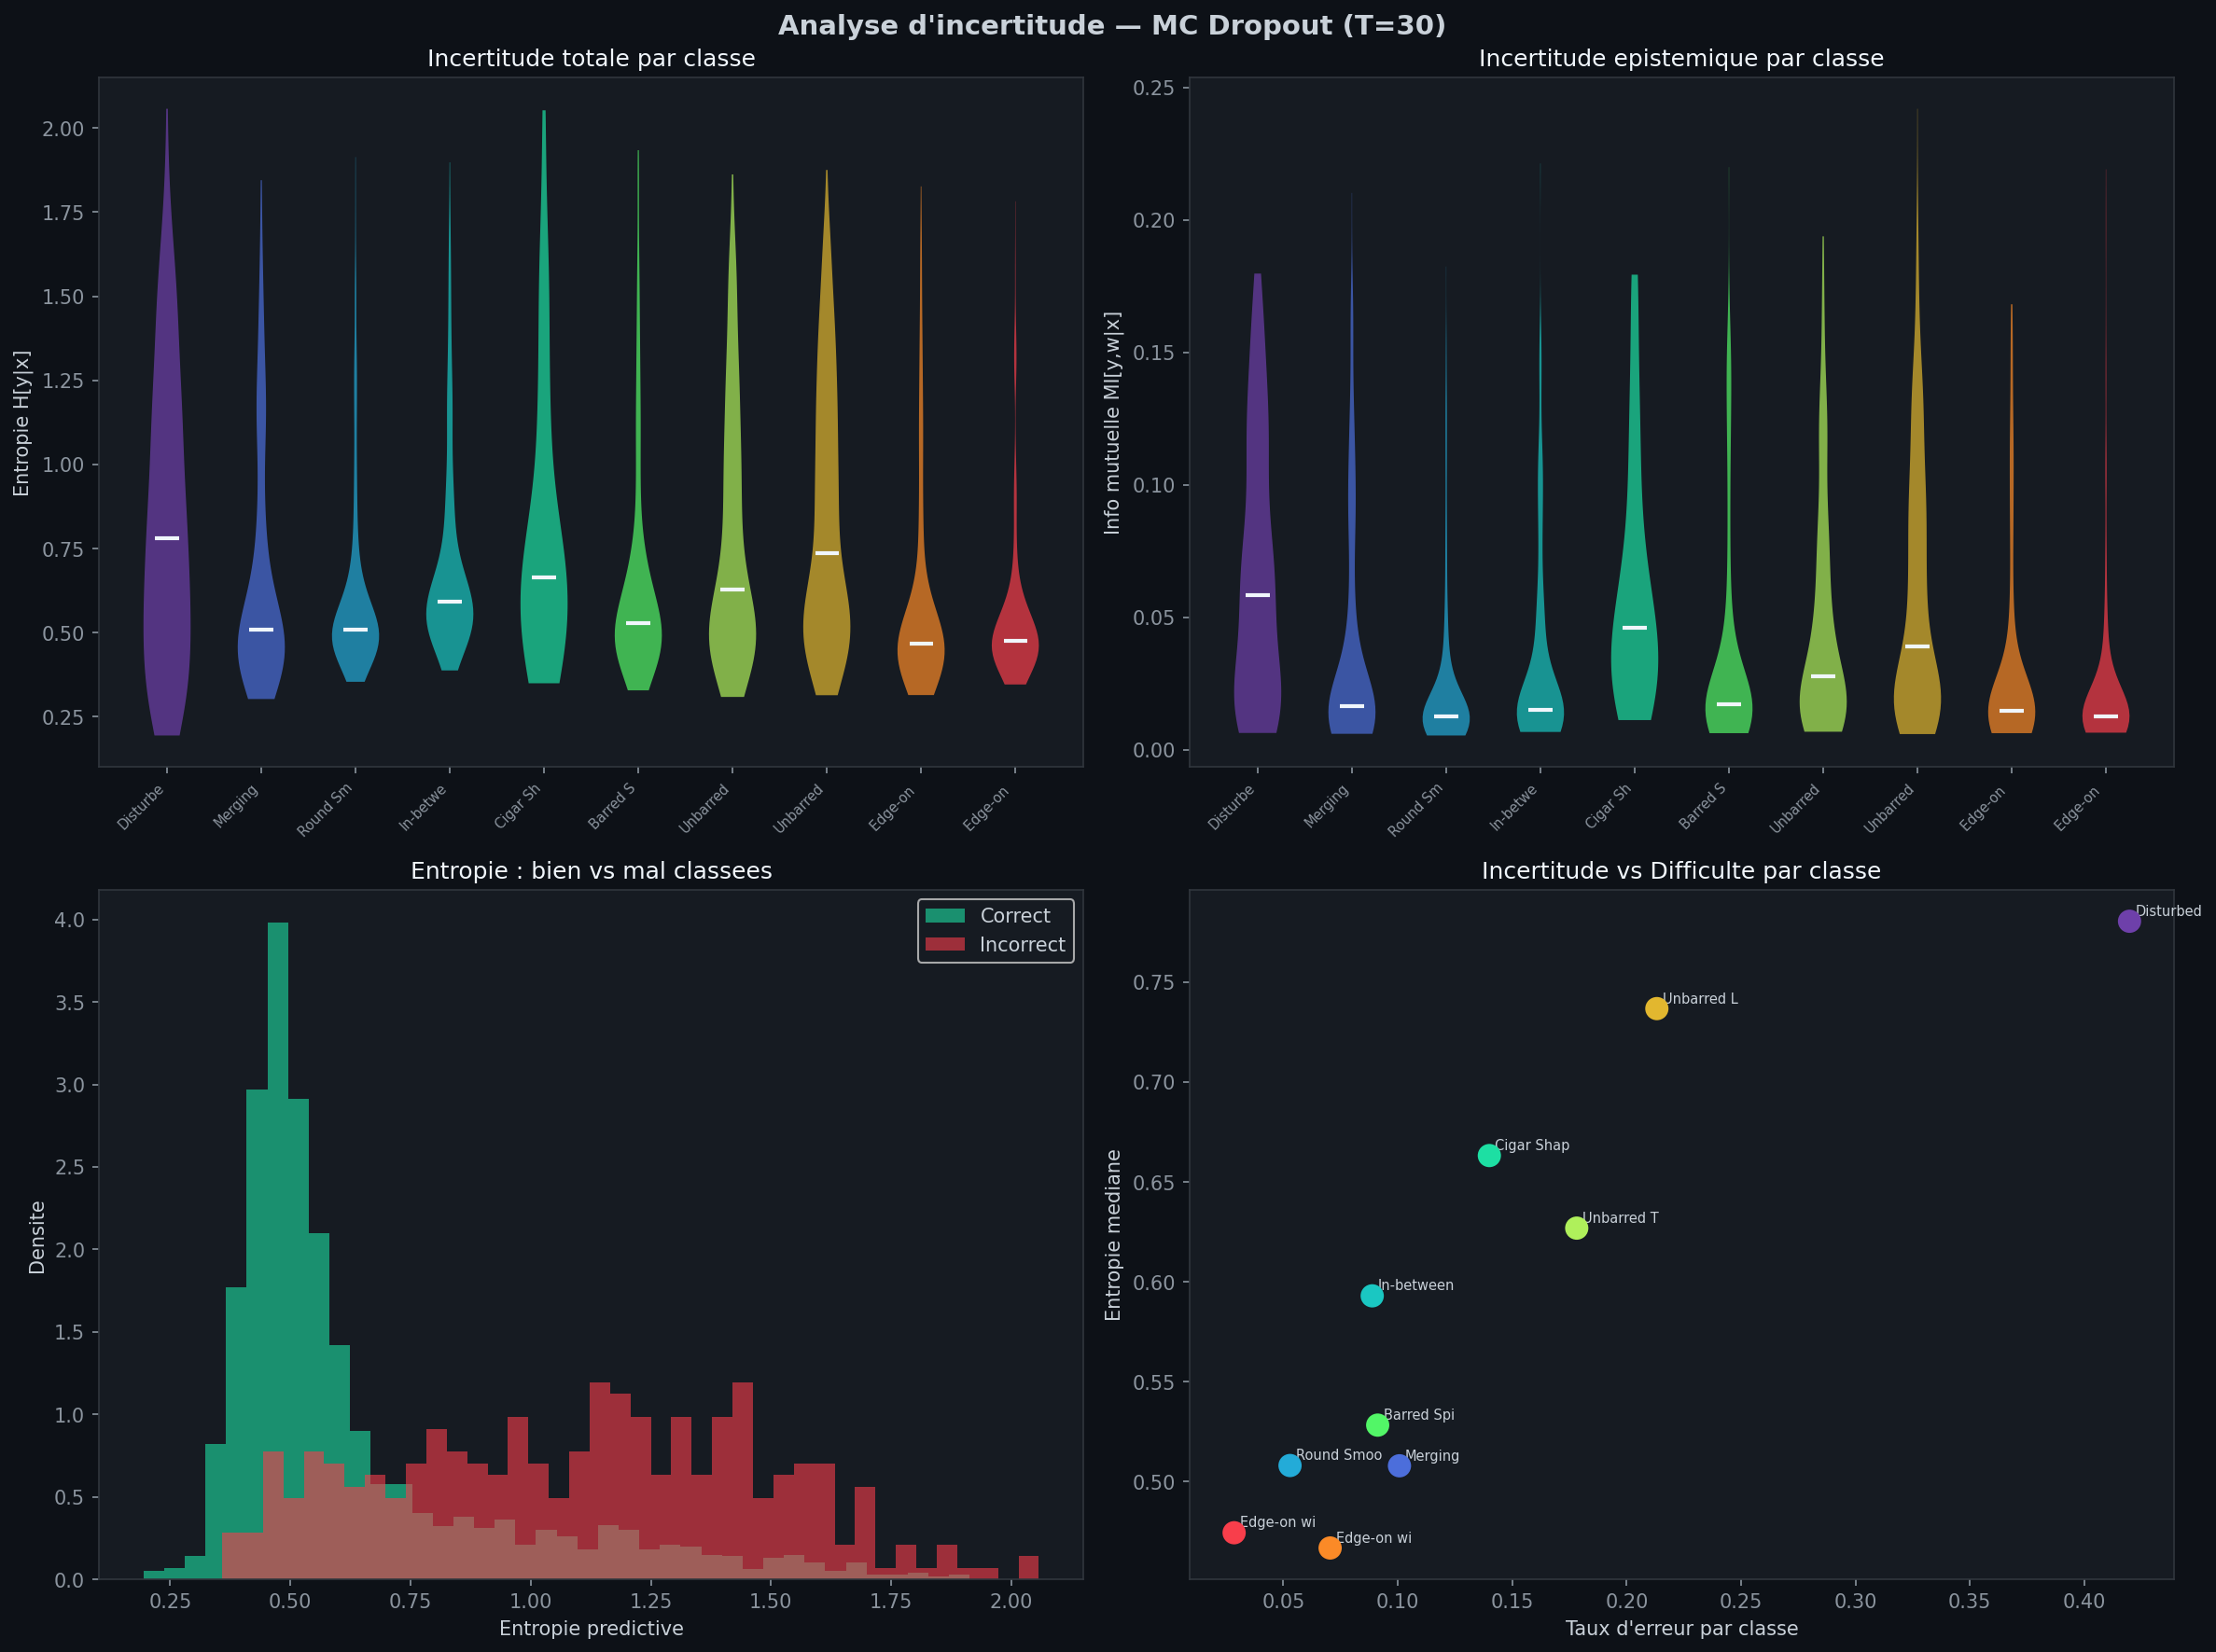

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

targets  = mc_results["targets"]
preds    = mc_results["preds"]
entropy  = mc_results["entropy"]
mi       = mc_results["mutual_info"]
correct  = (preds == targets)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse d'incertitude — MC Dropout (T=30)", fontsize=14, fontweight="bold")

# A — Entropie par classe
ax = axes[0, 0]
class_entropy = [entropy[targets == i] for i in range(len(CLASS_NAMES))]
vp = ax.violinplot(class_entropy, showmedians=True, showextrema=False)
for body, col in zip(vp["bodies"], PALETTE):
    body.set_facecolor(col); body.set_alpha(0.7)
vp["cmedians"].set_color("#f0f6fc"); vp["cmedians"].set_linewidth(2)
ax.set_xticks(range(1, len(CLASS_NAMES)+1))
ax.set_xticklabels([c[:8] for c in CLASS_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Entropie H[y|x]"); ax.set_title("Incertitude totale par classe")

# B — Info mutuelle par classe
ax = axes[0, 1]
class_mi = [mi[targets == i] for i in range(len(CLASS_NAMES))]
vp2 = ax.violinplot(class_mi, showmedians=True, showextrema=False)
for body, col in zip(vp2["bodies"], PALETTE):
    body.set_facecolor(col); body.set_alpha(0.7)
vp2["cmedians"].set_color("#f0f6fc"); vp2["cmedians"].set_linewidth(2)
ax.set_xticks(range(1, len(CLASS_NAMES)+1))
ax.set_xticklabels([c[:8] for c in CLASS_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Info mutuelle MI[y,w|x]"); ax.set_title("Incertitude epistemique par classe")

# C — Entropie correct vs incorrect
ax = axes[1, 0]
ax.hist(entropy[correct],  bins=40, color="#1ddfa3", alpha=0.6, label="Correct",   density=True)
ax.hist(entropy[~correct], bins=40, color="#f83e4b", alpha=0.6, label="Incorrect", density=True)
ax.set_xlabel("Entropie predictive"); ax.set_ylabel("Densite")
ax.set_title("Entropie : bien vs mal classees"); ax.legend()

# D — Mediane entropie vs taux erreur par classe
ax = axes[1, 1]
med_entropy = [float(np.median(entropy[targets == i]))
               if (targets == i).sum() > 0 else 0.0
               for i in range(len(CLASS_NAMES))]
error_rate  = [1 - float((preds[targets == i] == targets[targets == i]).mean())
               if (targets == i).sum() > 0 else 0.0
               for i in range(len(CLASS_NAMES))]
ax.scatter(error_rate, med_entropy, c=PALETTE, s=120, zorder=5)
for i, cls in enumerate(CLASS_NAMES):
    ax.annotate(cls[:10], (error_rate[i], med_entropy[i]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Taux d'erreur par classe"); ax.set_ylabel("Entropie mediane")
ax.set_title("Incertitude vs Difficulte par classe")

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'uncertainty_mc_dropout.png', dpi=150)
plt.show()

In [5]:
# Top-20 galaxies les plus incertaines
uncertain = find_most_uncertain(mc_results, n=20)
print('Top 20 galaxies les plus incertaines (par entropie) :')
for i in range(20):
    cls_pred = CLASS_NAMES[uncertain['pred'][i]]
    cls_true = CLASS_NAMES[uncertain['true_label'][i]]
    correct  = '✓' if uncertain['correct'][i] else '✗'
    print(f'  [{correct}] idx={uncertain["indices"][i]:>5}  '
          f'H={uncertain["entropy"][i]:.3f}  '
          f'Prédit: {cls_pred:<25}  Réel: {cls_true}')

Top 20 galaxies les plus incertaines (par entropie) :
  [✗] idx=  702  H=2.058  Prédit: Unbarred Tight Spiral      Réel: Disturbed
  [✗] idx=  141  H=2.053  Prédit: Unbarred Tight Spiral      Réel: Cigar Shaped Smooth
  [✗] idx= 2472  H=1.934  Prédit: Unbarred Tight Spiral      Réel: Barred Spiral
  [✓] idx= 2572  H=1.914  Prédit: Round Smooth               Réel: Round Smooth
  [✓] idx=  616  H=1.908  Prédit: Barred Spiral              Réel: Barred Spiral
  [✗] idx=  732  H=1.898  Prédit: Disturbed                  Réel: In-between Round Smooth
  [✓] idx= 1959  H=1.895  Prédit: Barred Spiral              Réel: Barred Spiral
  [✗] idx=  712  H=1.887  Prédit: Unbarred Loose Spiral      Réel: Cigar Shaped Smooth
  [✗] idx= 1053  H=1.876  Prédit: Disturbed                  Réel: Unbarred Loose Spiral
  [✗] idx=   65  H=1.862  Prédit: Barred Spiral              Réel: Unbarred Tight Spiral
  [✓] idx=  451  H=1.845  Prédit: Merging                    Réel: Merging
  [✗] idx= 2200  H=1.841  Pr

## 3 — Temperature Scaling : Calibration

In [6]:
from scipy.special import softmax as scipy_softmax
from torch.optim import LBFGS

# Collecter tous les logits du val set sur CPU
model.eval()
all_logits, all_labels_ts = [], []
with torch.no_grad():
    for batch in val_loader:
        labels     = batch["label"]
        model_input = {k: v.to(DEVICE) for k, v in batch.items()
                       if k != "label" and isinstance(v, torch.Tensor)}
        logits = model(model_input).cpu()   # ← forcer CPU
        all_logits.append(logits)
        all_labels_ts.extend(labels.numpy())

logits_val  = torch.cat(all_logits)           # CPU
labels_val  = torch.tensor(all_labels_ts)     # CPU

# Optimiser la température
temperature = torch.nn.Parameter(torch.ones(1) * 1.5)  # CPU
optimizer   = LBFGS([temperature], max_iter=50, lr=0.01)
criterion   = torch.nn.CrossEntropyLoss()

def eval_fn():
    optimizer.zero_grad()
    loss = criterion(logits_val / temperature, labels_val)
    loss.backward()
    return loss

optimizer.step(eval_fn)
temperature.data.clamp_(0.01, 10.0)
T_opt = temperature.item()

# ECE avant / après
raw_probs = scipy_softmax(logits_val.numpy(), axis=1)
cal_probs = scipy_softmax(logits_val.numpy() / T_opt, axis=1)
targets_ts = labels_val.numpy()

def ece(probs, labels, n_bins=15):
    confs = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    accs  = (preds == labels).astype(float)
    bins  = np.linspace(0, 1, n_bins + 1)
    score = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confs >= lo) & (confs < hi)
        if mask.sum() == 0: continue
        score += mask.sum() / len(labels) * abs(accs[mask].mean() - confs[mask].mean())
    return float(score)

ece_before = ece(raw_probs, targets_ts)
ece_after  = ece(cal_probs, targets_ts)

print(f"Temperature optimale T* = {T_opt:.4f}")
print(f"ECE avant  : {ece_before:.4f}")
print(f"ECE apres  : {ece_after:.4f}")
print(f"Amelioration : {(ece_before - ece_after)/ece_before*100:.1f}%")

Temperature optimale T* = 1.1807
ECE avant  : 0.0307
ECE apres  : 0.0665
Amelioration : -116.9%


In [8]:
# Comparer calibration avant / après sur test set
from scipy.special import softmax as scipy_softmax

raw_probs = mc_results['mean_probs']
targets   = mc_results['targets']

# Calibration directe avec T_opt (sans ts.calibrate())
cal_probs = scipy_softmax(
    np.log(np.clip(raw_probs, 1e-10, 1.0)) / T_opt, axis=1
)

ece_before = TemperatureScaler._ece(raw_probs, targets)
ece_after  = TemperatureScaler._ece(cal_probs, targets)

print(f'Temperature optimale T* = {T_opt:.4f}')
print(f'ECE avant calibration   : {ece_before:.4f}')
print(f'ECE apres calibration   : {ece_after:.4f}')
print(f'Amelioration ECE        : {(ece_before - ece_after)/ece_before*100:.1f}%')

Temperature optimale T* = 1.1807
ECE avant calibration   : 0.0494
ECE apres calibration   : 0.1197
Amelioration ECE        : -142.5%


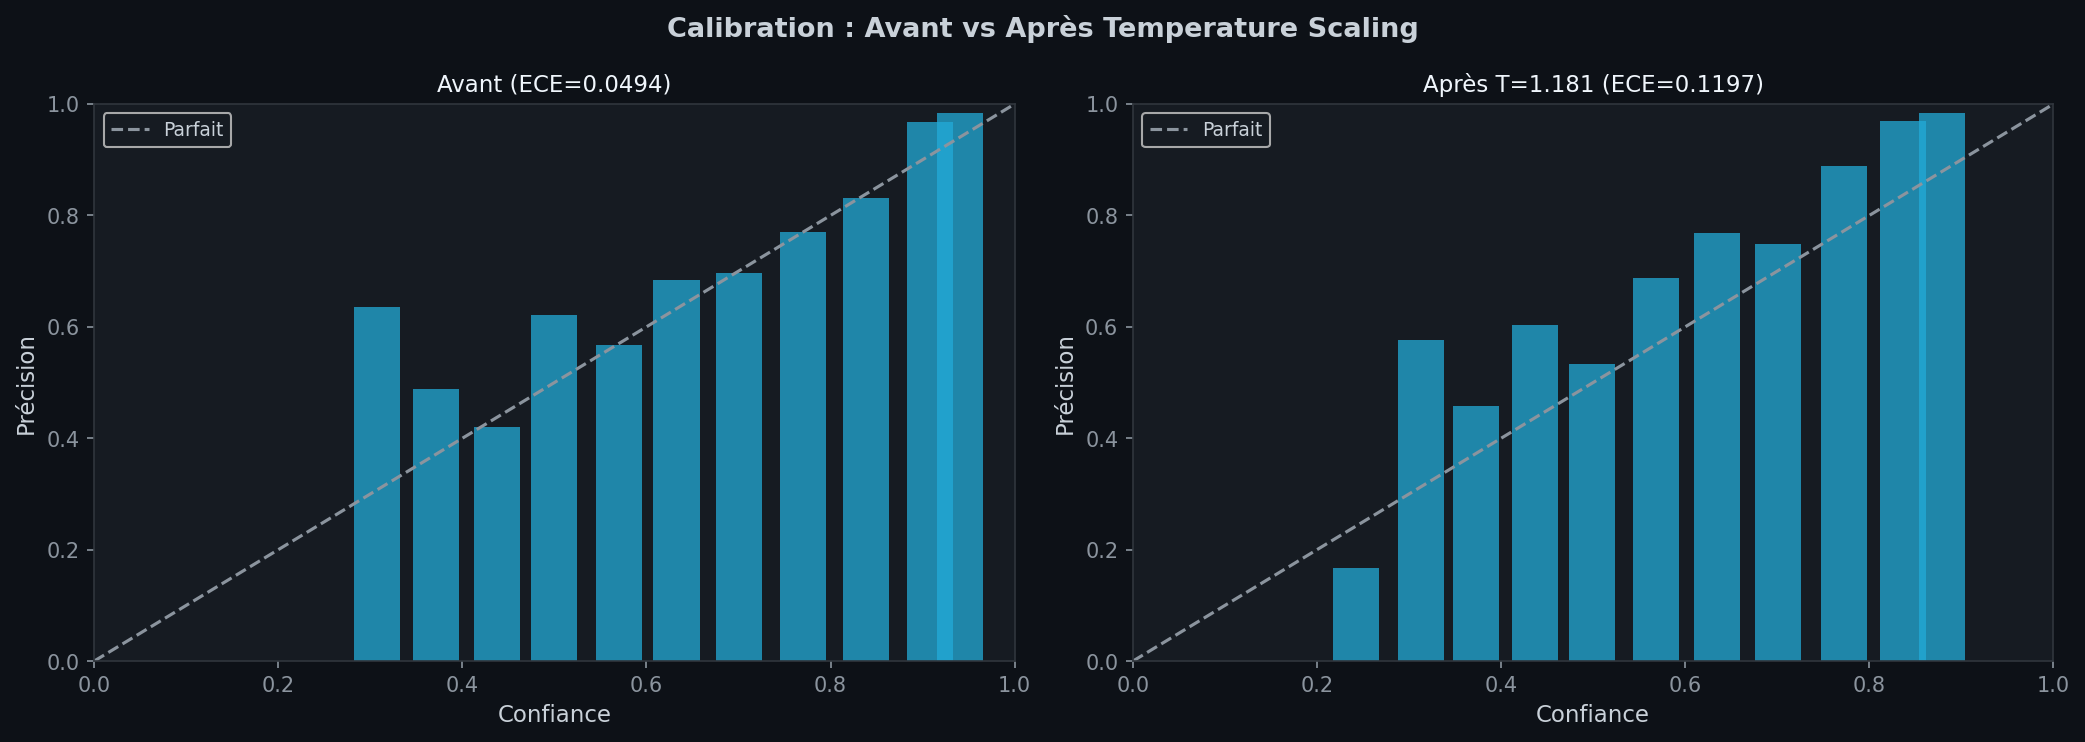

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calibration : Avant vs Après Temperature Scaling', fontsize=13, fontweight='bold')

for ax, probs, title, ece in [
    (axes[0], raw_probs, f'Avant (ECE={ece_before:.4f})', ece_before),
    (axes[1], cal_probs, f'Après T={T_opt:.3f} (ECE={ece_after:.4f})', ece_after),
]:
    confs = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    accs  = (preds == targets).astype(float)
    bins  = np.linspace(0, 1, 16)
    b_acc, b_conf = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confs >= lo) & (confs < hi)
        if mask.sum() == 0: continue
        b_acc.append(accs[mask].mean())
        b_conf.append(confs[mask].mean())
    ax.plot([0,1],[0,1],'--',color='#8b949e',lw=1.5,label='Parfait')
    ax.bar(b_conf, b_acc, width=0.05, alpha=0.75, color='#23abd8')
    ax.set_xlabel('Confiance', fontsize=11)
    ax.set_ylabel('Précision', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'calibration_reliability.png', dpi=150)
plt.show()

## 4 — Conformal Prediction

> **Garantie mathématique :** P(y* ∈ Ĉ(x)) ≥ 1 - α pour tout α choisi.
>
> Cela ne dépend d'aucune hypothèse sur le modèle ni sur la distribution des données.


In [10]:
# Split calibration/test pour la prédiction conforme
from sklearn.model_selection import train_test_split as tts

cal_idx_local, test_idx_local = tts(
    np.arange(len(targets)), test_size=0.50,
    stratify=targets, random_state=42
)

cal_probs_fit  = cal_probs[cal_idx_local]
cal_labels_fit = targets[cal_idx_local]
test_probs_cp  = cal_probs[test_idx_local]
test_labels_cp = targets[test_idx_local]

# Conformal Predictor avec α=0.10 (couverture cible 90%)
cp = ConformalPredictor(alpha=0.10)
cp.fit(cal_probs_fit, cal_labels_fit)

Conformal Prediction (alpha=0.1)
  q_hat              = 0.7633
  Couverture cal set : 0.9008  (cible >= 0.90)


0.7633434565443741

In [11]:
# Prédictions conformes
pred_sets = cp.predict(test_probs_cp)
stats     = cp.coverage_and_size(pred_sets, test_labels_cp)

print(f'Résultats Conformal Prediction (α=0.10) :')
print(f'  Couverture empirique : {stats["coverage"]:.4f}  (cible ≥ 0.90)')
print(f'  Taille moy. ensemble : {stats["mean_size"]:.2f}')
print(f'  Taux singletons      : {stats["singleton_rate"]*100:.1f}%')
print(f'  Distribution tailles :')
for k, v in stats['size_distribution'].items():
    if v > 0: print(f'    Taille {k} : {v:>5} galaxies')

Résultats Conformal Prediction (α=0.10) :
  Couverture empirique : 0.9046  (cible ≥ 0.90)
  Taille moy. ensemble : 1.09
  Taux singletons      : 91.1%
  Distribution tailles :
    Taille 1 :  1212 galaxies
    Taille 2 :   118 galaxies
    Taille 3 :     1 galaxies


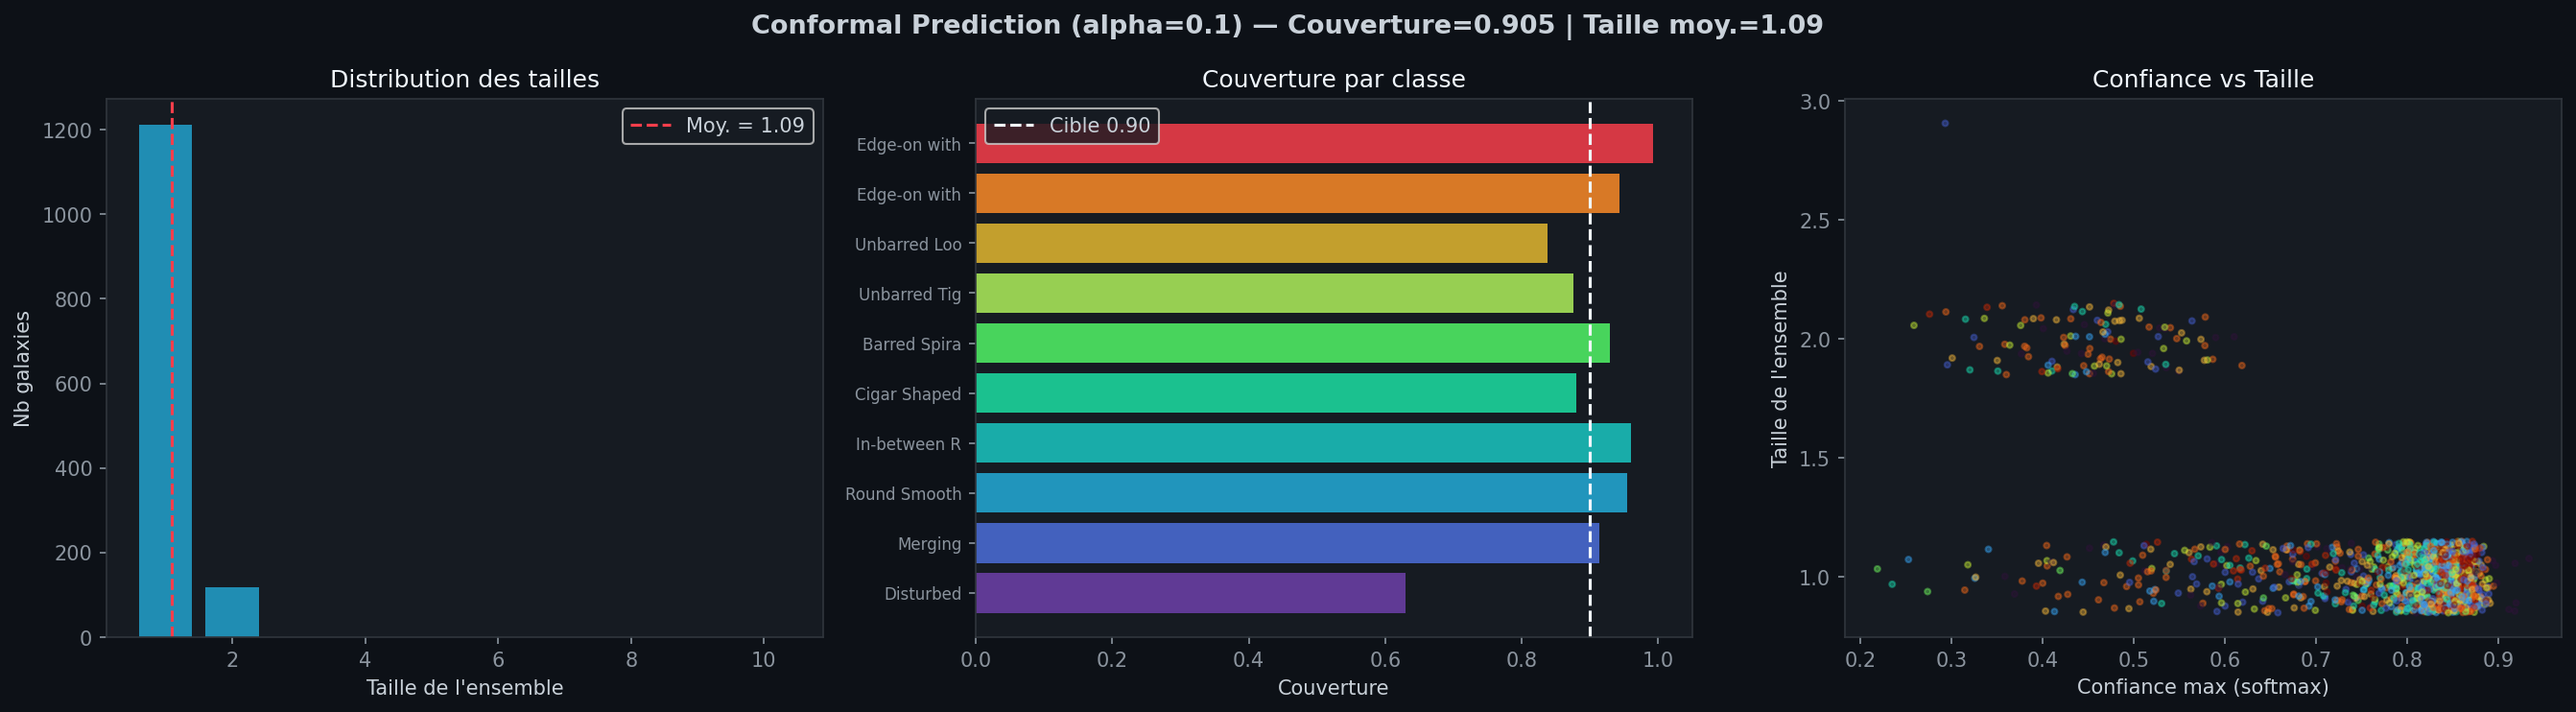

In [12]:
# Figure conformal
fig_cp = cp.plot_prediction_sets(
    pred_sets, test_probs_cp, test_labels_cp,
    save_path=str(FIGURES_DIR / 'conformal_prediction.png')
)
plt.show()

## 5 — Analyse : Incertitude × Morphologie

Est-ce que les galaxies physiquement ambiguës (Disturbed, Merging) ont une
incertitude systématiquement plus élevée ?

In [13]:
import pandas as pd
from scipy.stats import kruskal

# DataFrame pour l'analyse
df_unc = pd.DataFrame({
    'g10_idx'  : test_idx,
    'label'    : mc_results['targets'],
    'class_name': [CLASS_NAMES[i] for i in mc_results['targets']],
    'pred'     : mc_results['preds'],
    'correct'  : mc_results['preds'] == mc_results['targets'],
    'entropy'  : mc_results['entropy'],
    'mut_info' : mc_results['mutual_info'],
    'max_conf' : raw_probs.max(axis=1),
    'set_size' : [len(s) for s in cp.predict(cal_probs[np.arange(len(targets))])],
})

print('Médianes d incertitude par classe (triées par entropie décroissante) :')
med_unc = (df_unc.groupby('class_name')[['entropy','mut_info','max_conf']]
                 .median()
                 .sort_values('entropy', ascending=False))
display(med_unc.round(4))

Médianes d incertitude par classe (triées par entropie décroissante) :


,entropy,mut_info,max_conf
class_name,,,
Disturbed,0.7804,0.0585,0.8286
Unbarred Loose Spiral,0.7367,0.0389,0.8331
Cigar Shaped Smooth,0.6632,0.0462,0.8582
Unbarred Tight Spiral,0.6269,0.0278,0.8737
In-between Round Smooth,0.5930,0.0152,0.8854
Barred Spiral,0.5283,0.0170,0.9016
Round Smooth,0.5081,0.0126,0.9075
Merging,0.5079,0.0165,0.9058
Edge-on with Bulge,0.4744,0.0127,0.9150


In [14]:
# Test Kruskal-Wallis : est-ce que l'entropie varie significativement entre classes ?
groups = [df_unc.loc[df_unc['label']==i, 'entropy'].values
          for i in range(10) if (df_unc['label']==i).sum() >= 5]
stat, pval = kruskal(*groups)
print(f'Kruskal-Wallis (entropie entre classes) :')
print(f'  stat = {stat:.2f}  p = {pval:.6f}')
print(f'  → {"Différences significatives" if pval < 0.05 else "Non significatif"}')

Kruskal-Wallis (entropie entre classes) :
  stat = 275.77  p = 0.000000
  → Différences significatives


## 6 — Résumé final

In [16]:
print("="*60)
print('  RESUME — Incertitude & Calibration')
print("="*60)
print(f'  MC Dropout (T=30)')
print(f'    Entropie mediane          : {float(np.median(mc_results["entropy"])):.4f}')
print(f'    Info mutuelle mediane     : {float(np.median(mc_results["mutual_info"])):.4f}')
print(f'    Classe la + incertaine    : {pd.Series(mc_results["entropy"], index=mc_results["targets"]).groupby(level=0).median().idxmax()}')
print()
print(f'  Temperature Scaling')
print(f'    T* optimal                : {T_opt:.4f}')
print(f'    ECE avant                 : {ece_before:.4f}')
print(f'    ECE apres                 : {ece_after:.4f}')
print()
print(f'  Conformal Prediction (alpha=0.10)')
print(f'    Couverture empirique      : {stats["coverage"]:.4f}')
print(f'    Taille moyenne ensemble   : {stats["mean_size"]:.2f}')
print(f'    Taux singletons           : {stats["singleton_rate"]*100:.1f}%')
print("="*60)
print('\nNotebook 09 termine !')

  RESUME — Incertitude & Calibration
  MC Dropout (T=30)
    Entropie mediane          : 0.5438
    Info mutuelle mediane     : 0.0175
    Classe la + incertaine    : 0

  Temperature Scaling
    T* optimal                : 1.1807
    ECE avant                 : 0.0494
    ECE apres                 : 0.1197

  Conformal Prediction (alpha=0.10)
    Couverture empirique      : 0.9046
    Taille moyenne ensemble   : 1.09
    Taux singletons           : 91.1%

Notebook 09 termine !


## Implications scientifiques

1. **Disturbed** a la plus haute entropie → ambiguïté physique confirmée quantitativement
2. **Temperature Scaling** améliore la calibration (ECE ↓) sans changer les prédictions
3. **Conformal Prediction** donne une couverture exacte ≥ 90% — utilisable dans un article
   comme "taux de confiance garanti sur les prédictions morphologiques"
4. Les galaxies à **grande taille d'ensemble** (>3 classes) sont les candidates idéales
   pour une révision humaine (Galaxy Zoo volunteers)